In [8]:
### Requires gdstk
import muspan as ms
from muspan.query.return_object_IDs_from_query_like import return_object_IDs_from_query_like
import gdstk
import math
from itertools import zip_longest
from matplotlib import pyplot as plt
import numpy as np
from typing import List, Tuple, Optional


def bootstrap_ci_positions(
    data: List[List[float]],
    n_bootstrap: int = 1000,
    ci: float = 95.0,
    statistic: str = 'mean',          # 'mean' or 'median'
    seed: Optional[int] = None
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Bootstrap CI per position using numpy.

    Returns tuple of 4 arrays (each length = max_length_of_lists):
      n_valids:   int array of how many non-NaN values at each position
      points:     point estimate (mean/median) from observed data at each position
      ci_lower:   lower percentile
      ci_upper:   upper percentile

    Notes:
    - Positions where n_valid == 0 will have NaN for point, ci_lower, ci_upper.
    - For reproducibility pass an integer seed.
    """
    if statistic not in ('mean', 'median'):
        raise ValueError("statistic must be 'mean' or 'median'")

    # convert None to np.nan and pad to rectangular array
    max_len = max((len(lst) for lst in data), default=0)
    arr = np.full((len(data), max_len), np.nan, dtype=float)
    for i, lst in enumerate(data):
        # replace None with np.nan automatically by assignment via float conversion
        arr[i, :len(lst)] = [float(x) if x is not None else np.nan for x in lst]

    rng = np.random.default_rng(seed)

    n_positions = max_len
    n_valids = np.zeros(n_positions, dtype=int)
    points = np.full(n_positions, np.nan, dtype=float)
    ci_lower = np.full(n_positions, np.nan, dtype=float)
    ci_upper = np.full(n_positions, np.nan, dtype=float)

    lower_q = (100.0 - ci) / 2.0
    upper_q = 100.0 - lower_q

    for pos in range(n_positions):
        col = arr[:, pos]
        valid = col[~np.isnan(col)]
        n_valid = valid.size
        n_valids[pos] = n_valid
        if n_valid == 0:
            continue

        # observed point estimate
        if statistic == 'mean':
            points[pos] = valid.mean()
        else:
            points[pos] = np.median(valid)

        # draw bootstrap samples: shape (n_bootstrap, n_valid)
        # sample WITH replacement; each resample has size equal to original n_valid
        # Using Generator.choice is efficient
        samples = rng.choice(valid, size=(n_bootstrap, n_valid), replace=True)

        if statistic == 'mean':
            bs_stats = samples.mean(axis=1)
        else:
            bs_stats = np.median(samples, axis=1)

        # compute percentiles (numpy uses linear interpolation by default)
        ci_lower[pos] = np.percentile(bs_stats, lower_q, interpolation='linear')
        ci_upper[pos] = np.percentile(bs_stats, upper_q, interpolation='linear')

    return n_valids, points, ci_lower, ci_upper

def counts_for_ranges(distances, ranges, inclusive=True):
    """
    distances: 1D sequence of numbers
    ranges: iterable of (lo, hi) tuples
    inclusive: if True, count lo <= x <= hi; if False, count lo <= x < hi
    Returns: total_count, np.array(counts) (same order as ranges)
    """
    if len(distances) == 0:
        return 0, np.zeros(len(ranges), dtype=int)

    arr = np.asarray(distances)
    # filter NaNs if present (optional)
    arr = arr[~np.isnan(arr)]

    sorted_arr = np.sort(arr)  # O(N log N)
    lows = np.array([lo for lo, hi in ranges])
    highs = np.array([hi for lo, hi in ranges])

    # left indices: first index >= low
    left_idx = np.searchsorted(sorted_arr, lows, side='left')
    # right indices depend on inclusive flag
    side_for_hi = 'right' if inclusive else 'left'
    right_idx = np.searchsorted(sorted_arr, highs, side=side_for_hi)

    counts = right_idx - left_idx
    return sorted_arr.size, counts

def shapedcrosspcf(domain, shape, population, step, width, visualise_shapes=False, collection_or_label = 'collection', return_outputs = False):
    """
    Carry out shaped cross-pcf analysis - returning the relative density of a given population in concentric regions within a shape.
    Warning: will take a long time to run if the population is large

    Parameters
    ----------
    domain : muspan domain
        The domain containing the objects.
    shape : collection
        The collection name of a shape within which you would like to carry out the shaped cross-pcf.
        Can be a collection of several shapes.
    population : collection or label
        the collection or label of the objects that you would like to compute the shaped cross-pcf metric for
    step : int
        the step between each ring in which the relative density is calculated
    width : int
        must be a multiple of step (for now), the width of the region in which relative density is calculated
    visualise_shapes : bool, optional
        defaults to False. Specifies whether you would like to visualise the concentric shapes in which the relative 
        densities are calculated
    collection_or_label : string
        defaults to 'collection'. Specifies whether your population entry is a collection or a label. Must be either
        'collection' or 'label'
    return_outputs : bool, optional
        defaults to False. Specifies whether you would like the relative densities, mean densities and confidence intervals returned. 
        If False, the function simply plots the output, if true, see returns.
    
        
    Returns
    -------
    all_densities : list
        A list of lists containing the relative densities of cells at each concentric region, from outermost to innermost. 
        Each sublist corresponds to a subshape of the specified shape.
    distances_from_boundary : list
        A list of the distances from the boundary of the outer edge of the ring. The indices of these distances correspond 
        to the indices of relative densities in the lists of all/relative densities and the confidence intervals of the densities.
    average_densities : list
        The average relative density for the ring at each distance from the shape boundary
    confidence_intervals : list
        The confidence intervals for the relative density for the ring at each distance from the shape boundary. Obtained by 
        bootstrapping across subregions 2000 times.
    """

    ### cell_type : collection or label
        # the collection or label of the objects that you would like to compute the shaped cross-pcf metric for - soon you will be able to calculate
        # for several cell types and return each one separately - currently need to set cell type to population, this is just here for future purposes
    if width % step != 0:
        raise Exception('Width must be divisible by step')
    # set up plot
    if visualise_shapes == True:
        colours = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000']
        fig, axes = plt.subplots(1, 1, figsize=(8, 8))
    fig1, axes1 = plt.subplots(1, 1, figsize=(8, 8))

    # find all subshapes in shape collection
    shapes_ID=ms.query.interpret_query(ms.query.query(domain, ('collection',),'is',shape))
    all_densities = []
    # loop through each subshape
    for shapes_counter in range(len(shapes_ID)):
        shape_ID = shapes_ID[shapes_counter]

        ### Label cells inside shape
        if collection_or_label == 'collection':
            query_cell = ms.query.query(domain, ('collection',), 'is', population)
        elif collection_or_label == 'label':
            query_cell = ms.query.query(domain, ('label', 'Detailed celltype (liver)'), 'is', population)
        else:
            raise Exception('collection_or_label must be either \'collection\' or \'label\'.')
        
        cell_IDs = ms.query.return_object_IDs_from_query_like(domain,query_cell,bypass_checks=True)

        query_contained = ms.query.query(domain,('contains',(query_cell,  [shape_ID])), 'is', True)
        domain.add_objects_to_collection(query_contained, collection_name = str(shape)+str(shapes_counter)+'_cells')


        ### Calculate distance to boundary from these points
        shape_cells = ms.query.return_object_IDs_from_query_like(domain, ('collection', str(shape)+str(shapes_counter)+'_cells'),bypass_checks=True) 
        # shape_cells_counter = ms.query.return_object_IDs_from_query_like(domain, ('collection', str(shape)+str(shapes_counter)+'_cells'),  bypass_checks=True)

        shape_cell_distances = [None] * len(shape_cells)
        labels = [None] * len(shape_cells)
        shape_distances = [None] * len(shape_cells)
        k = 0
        for cell_ID in shape_cells:
            
            distances = ms.helpers.object_to_object_distance_matrix(domain, population_A=[cell_ID], population_B=[shape_ID])
            distance = np.min(distances)
            shape_cell_distances[k] = [cell_ID, distance]
            k+=1

        ### Calculate densities in each region
        # export vertices of shape from MuSpAn
    
        shape_single = domain.objects[shape_ID]
        vs_ext = domain.vertices[shape_single.vertices].tolist()
        poly = gdstk.Polygon(vs_ext)

        if shape_single.internal_vertices:   
            internal_shapes_list = []
            for internal_shape in shape_single.internal_vertices:
                vs_int = domain.vertices[internal_shape].tolist()
                internal_shapes_list.append(gdstk.Polygon(vs_int))
            for inner in internal_shapes_list:
                poly = gdstk.boolean(poly, inner, "not")
            area = poly[0].area()
        else:
            area = poly.area()
        # convert to polygons
        # poly = gdstk.Polygon(poly)
        
        all_offset_shapes = []
        
        areas = []
        i = 0
        while area > 0:
        # find offset polygon for each step
            eroded = gdstk.offset(poly, -i,
                            use_union=True, layer=1)
            offset_shapes = []
            offset_shapes_areas = []
            for j in range(len(eroded)):
                offset_shapes_areas.append(eroded[j].area())
                offset_shapes.append(eroded[j])
                if visualise_shapes == True:
                    xs = [x[0] for x in eroded[j].points]
                    xs.append(xs[0])
                    ys = [x[1] for x in eroded[j].points]
                    ys.append(ys[0])
                    axes.plot(xs, ys, color = colours[math.floor(i) % len(colours)])

            if offset_shapes == []:
                area = 0
            else:
                area = np.max(np.array(offset_shapes_areas))
            all_offset_shapes.append(offset_shapes)
            areas.append(offset_shapes_areas)
            i +=step
    

        # Find areas of each region
        widthsteprat = int(width/step)
        ring_areas = []

        for depth in range(len(areas)-widthsteprat-1):
            ring_areas.append(np.sum(areas[depth])-np.sum(areas[depth+widthsteprat]))

        # find cell densities in each region

        ### Come back to this later to go over multiple cell types
        cell_type = population
        if collection_or_label == 'collection':
            query_cell = ms.query.query(domain, ('collection',), 'is', cell_type)
        else:
            query_cell = ms.query.query(domain, ('label', 'Detailed celltype (liver)'), 'is', cell_type)
        specific_cell_IDs = ms.query.return_object_IDs_from_query_like(domain,query_cell,bypass_checks=True)

        ### for multiple cell types in population, need to add filter to distances first

        ### count number of cells of interest in total region and in each specific strip
        if len(areas)-widthsteprat-1 > 0:
            ranges = list(zip(range(0, (len(areas)-int(widthsteprat)-1)*step, step), range(width, (len(areas)-1)*step, step)))
            distances = [sublist[1] for sublist in shape_cell_distances]
            total_cells, cell_counts = counts_for_ranges(distances, ranges)

            ### calculate overall density
            overall_density = total_cells/areas[0][0]
            densities = []
            rel_densities = []

            ### calculate concentric relative densities
            for i in range(len(ring_areas)):
                densities.append(cell_counts[i]/ring_areas[i])
                rel_densities.append((cell_counts[i]/ring_areas[i])/overall_density)
            x = range(0, (len(areas)-widthsteprat-1)*step, step)
            axes1.plot(x, rel_densities, alpha = 0.1)
            all_densities.append(rel_densities)
    
    ### Bootstrap densities...    
    average_densities = []
    for items in zip_longest(*all_densities, fillvalue=None):
        # Filter out None and NaN
        valid = [x for x in items if x is not None and not (isinstance(x, float) and np.isnan(x))]
        if valid:
            average_densities.append(sum(valid) / len(valid))
        else:
            average_densities.append(float('nan')) 

    n_valids, points, lo, hi = bootstrap_ci_positions(
        all_densities, n_bootstrap=2000, ci=95.0, statistic='mean', seed=42
    )
    x = range(0, (len(average_densities))*step, step)
    axes1.plot(x, average_densities, linestyle = 'dashed', color = 'k')

    axes1.fill_between(x, lo, hi, color='b', alpha=.1)
    axes1.axhline(1, linestyle='--', color = 'black', linewidth=1, alpha = 0.5)
    ### Label Plot
    axes1.set_title('Concentric Relative Densities for ' + str(cell_type) + '.')
    axes1.set_xlabel('Distance from '+str(shape)+' boundary.')
    axes1.set_ylabel('Relative Density.')

    if return_outputs == True:
        confidence_intervals = []
        for a, b in zip(lo, hi):
            confidence_intervals.append( [ a, b ] )
        distances_from_boundary = x
        return all_densities, distances_from_boundary, average_densities, confidence_intervals

In [17]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import muspan as ms
from itertools import zip_longest
from typing import List, Tuple, Optional
import math
from functools import partial
import seaborn as sns
from scipy import stats
import pathlib
import gdstk

In [2]:
directory = pathlib.Path("../outputs/In_out")
i=0
list_of_files = []
for item in directory.rglob("*"):
    if item.is_file():
            if str(item) != str(directory)+'/.DS_Store':
                list_of_files.append(str(item))
            i+=1
names = [x.replace('../domains_with_mets/', '').replace('.muspan', '') for x in list_of_files]

In [3]:
pc = ms.io.load_domain(list_of_files[0], print_summary=False)

In [9]:
keys = list(pc.labels.keys())

In [ ]:
print(keys)

In [11]:
list_of_domains = []
label_names = list(pc.labels.keys())

for i in range(len(list_of_files)):
    list_of_domains.append(ms.io.load_domain(list_of_files[i], print_summary=False))
    for label in label_names:
        if (label == 'Cell ID') or (label == 'Detailed celltype (liver)'):
            continue 
        list_of_domains[i].delete_labels(label)

In [12]:
met_nos = [1,1,2,3,7,17,2,23,13,4]
domains_order = ['AKPT_Liver_Mets_4d_2_Region_1', 
                'AKPT_Liver_Mets_4d_3_Region_1', 
                'AKPT_Liver_Mets_4d_1_Region_2', 
                'AKPT_Liver_Mets_4d_5_Region_1',
                'AKPT_Liver_Mets_28d_2_Region_2', 
                'AKPT_Liver_Mets_28d_1_Region_1', 
                'AKPT_Liver_Mets_4d_1_Region_1',
                'AKPT_Liver_Mets_28d_2_Region_1',
                'AKPT_Liver_Mets_28d_3_Region_1',
                'AKPT_Liver_Mets_28d_1_Region_2']
# AKPT_Liver_Mets_4d_4_Region_1

In [15]:
def counts_for_ranges_numpy(distances, ranges, inclusive=True):
    """
    distances: 1D sequence of numbers
    ranges: iterable of (lo, hi) tuples
    inclusive: if True, count lo <= x <= hi; if False, count lo <= x < hi
    Returns: total_count, np.array(counts) (same order as ranges)
    """
    if len(distances) == 0:
        return 0, np.zeros(len(ranges), dtype=int)

    arr = np.asarray(distances)
    # filter NaNs if present (optional)
    arr = arr[~np.isnan(arr)]

    sorted_arr = np.sort(arr)  # O(N log N)
    lows = np.array([lo for lo, hi in ranges])
    highs = np.array([hi for lo, hi in ranges])

    # left indices: first index >= low
    left_idx = np.searchsorted(sorted_arr, lows, side='left')
    # right indices depend on inclusive flag
    side_for_hi = 'right' if inclusive else 'left'
    right_idx = np.searchsorted(sorted_arr, highs, side=side_for_hi)

    counts = right_idx - left_idx
    return sorted_arr.size, counts

In [16]:
def bootstrap_ci_positions_numpy(
    data: List[List[float]],
    n_bootstrap: int = 1000,
    ci: float = 95.0,
    statistic: str = 'mean',          # 'mean' or 'median'
    seed: Optional[int] = None
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Bootstrap CI per position using numpy.

    Returns tuple of 4 arrays (each length = max_length_of_lists):
      n_valids:   int array of how many non-NaN values at each position
      points:     point estimate (mean/median) from observed data at each position
      ci_lower:   lower percentile
      ci_upper:   upper percentile

    Notes:
    - Positions where n_valid == 0 will have NaN for point, ci_lower, ci_upper.
    - For reproducibility pass an integer seed.
    """
    if statistic not in ('mean', 'median'):
        raise ValueError("statistic must be 'mean' or 'median'")

    # convert None to np.nan and pad to rectangular array
    max_len = max((len(lst) for lst in data), default=0)
    arr = np.full((len(data), max_len), np.nan, dtype=float)
    for i, lst in enumerate(data):
        # replace None with np.nan automatically by assignment via float conversion
        arr[i, :len(lst)] = [float(x) if x is not None else np.nan for x in lst]

    rng = np.random.default_rng(seed)

    n_positions = max_len
    n_valids = np.zeros(n_positions, dtype=int)
    points = np.full(n_positions, np.nan, dtype=float)
    ci_lower = np.full(n_positions, np.nan, dtype=float)
    ci_upper = np.full(n_positions, np.nan, dtype=float)

    lower_q = (100.0 - ci) / 2.0
    upper_q = 100.0 - lower_q

    for pos in range(n_positions):
        col = arr[:, pos]
        valid = col[~np.isnan(col)]
        n_valid = valid.size
        n_valids[pos] = n_valid
        if n_valid == 0:
            continue

        # observed point estimate
        if statistic == 'mean':
            points[pos] = valid.mean()
        else:
            points[pos] = np.median(valid)

        # draw bootstrap samples: shape (n_bootstrap, n_valid)
        # sample WITH replacement; each resample has size equal to original n_valid
        # Using Generator.choice is efficient
        samples = rng.choice(valid, size=(n_bootstrap, n_valid), replace=True)

        if statistic == 'mean':
            bs_stats = samples.mean(axis=1)
        else:
            bs_stats = np.median(samples, axis=1)

        # compute percentiles (numpy uses linear interpolation by default)
        ci_lower[pos] = np.percentile(bs_stats, lower_q, interpolation='linear')
        ci_upper[pos] = np.percentile(bs_stats, upper_q, interpolation='linear')

    return n_valids, points, ci_lower, ci_upper

In [ ]:
def shapedcrosspcfmedulla(list_of_domains, population, step, width, cortexstep, cortexwidth, visualise_shapes=False, collection_or_label = 'collection', return_outputs = False):
    """
    Carry out shaped cross-pcf analysis - returning the relative density of a given population in concentric regions within a shape.
    Warning: will take a long time to run if the population is large

    Parameters
    ----------
    domain : muspan domain
        The domain containing the objects.
    shape : collection
        The collection name of a shape within which you would like to carry out the shaped cross-pcf.
        Can be a collection of several shapes.
    population : collection or label
        the collection or label of the objects that you would like to compute the shaped cross-pcf metric for
    step : int
        the step between each ring in which the relative density is calculated
    width : int
        must be a multiple of step (for now), the width of the region in which relative density is calculated
    visualise_shapes : bool, optional
        defaults to False. Specifies whether you would like to visualise the concentric shapes in which the relative 
        densities are calculated
    collection_or_label : string
        defaults to 'collection'. Specifies whether your population entry is a collection or a label. Must be either
        'collection' or 'label'
    return_outputs : bool, optional
        defaults to False. Specifies whether you would like the relative densities, mean densities and confidence intervals returned. 
        If False, the function simply plots the output, if true, see returns.
    
        
    Returns
    -------
    all_densities : list
        A list of lists containing the relative densities of cells at each concentric region, from outermost to innermost. 
        Each sublist corresponds to a subshape of the specified shape.
    distances_from_boundary : list
        A list of the distances from the boundary of the outer edge of the ring. The indices of these distances correspond 
        to the indices of relative densities in the lists of all/relative densities and the confidence intervals of the densities.
    average_densities : list
        The average relative density for the ring at each distance from the shape boundary
    confidence_intervals : list
        The confidence intervals for the relative density for the ring at each distance from the shape boundary. Obtained by 
        bootstrapping across subregions 2000 times.
    """
    celltypes = ['WNT-high CRC stem-like cells', 'WNT-high CRC cells', 'Wnt-low CRC cells']
    label_name = 'Detailed celltype (liver)'

    colours = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000']
    list_of_axes = []
    list_of_figs = []
    list_of_max_met_dists = []
    list_of_max_out_dists = []
    all_met_distances = []
    all_out_distances = []
    all_regional_max_met_dists = []
    for dom in range(len(list_of_domains)):
        domain = list_of_domains[dom]
        met_no = met_nos[domains_order.index(str(domain.name))]
        one_domain_met_distances = []
        one_domain_out_distances = []
        for region_no in range(met_no):
            met_distances = np.load('../outputs/Useful_Data/'+str(domain.name)+'_inside_Met_'+str(region_no+1)+'.npy', allow_pickle=True)
            one_domain_met_distances.append(met_distances)
        out_distances = np.load('../outputs/Useful_Data/'+str(domain.name)+'_outside_to_all_Mets.npy', allow_pickle=True)
        # one_domain_out_distances.append(out_distances)
        all_out_distances.append(out_distances)
        all_met_distances.append(one_domain_met_distances)
    
    young_densities = []
    old_densities = []
    alt_young_densities = []
    alt_old_densities = []
    fig1, axes1 = plt.subplots(1, 1, figsize=(12, 8))
    # fig2, axes2 = plt.subplots(1, 1, figsize=(12, 8))

    all_met_areas = []
    max_areas = []
    for dom in range(len(list_of_domains)):
        domain = list_of_domains[dom]
        met_no = met_nos[domains_order.index(str(domain.name))]
        # domain.estimate_boundary('rectangle')
        # met distances
        max_met_dist=0
        regional_max_met_dists = []
        shape_cell_distances = all_met_distances[dom]
        met_areas = []
        for region_no in range(met_no):
            distances = shape_cell_distances[region_no][1]#[sublist[1] for sublist in shape_cell_distances[region_no]]
            regional_max_met_dists.append(np.max(distances))
            if np.max(distances) > max_met_dist:
                max_met_dist = np.max(distances)
            # print(domain)
            # ms.visualise.visualise(domain,objects_to_plot=('collection', 'Metastasis '+str(region_no+1)))
            met_areas.append(ms.geometry.area(domain, population=('collection', 'Metastasis '+str(region_no+1)))[0])
        all_met_areas.append(met_areas)
        max_areas.append(np.max(met_areas))        
        list_of_max_met_dists.append(max_met_dist)
        all_regional_max_met_dists.append(regional_max_met_dists)

    # for dom in range(len(list_of_domains)):
        # domain = list_of_domains[dom]
        # met_no = met_nos[domains_order.index(str(domain.name))]
        # # figures
        # fig, axes = plt.subplots(1, 1, figsize=(12, 8))
        # axes.set_title('KDEs for Cells in ' +str(domain.name)+'.')
        # axes.set_xlabel('Distance from Met Boundary.')
        # axes.set_ylabel('Density.')
        # list_of_axes.append(axes)
        # list_of_figs.append(fig)

        # # met distances
        # max_met_dist=0
        # regional_max_met_dists = []
        # shape_cell_distances = all_met_distances[dom]
        # for region_no in range(met_no):
        #     distances = shape_cell_distances[region_no][1]#[sublist[1] for sublist in shape_cell_distances[region_no]]
        #     regional_max_met_dists.append(np.max(distances))
        #     if np.max(distances) > max_met_dist:
        #         max_met_dist = np.max(distances)
        # list_of_max_met_dists.append(max_met_dist)
        # all_regional_max_met_dists.append(regional_max_met_dists)

        # # out distances
        # shape_cell_distances_out = all_out_distances[domains_order.index(str(domain.name))]
        # distances_out = [sublist[1] for sublist in shape_cell_distances_out]
        # list_of_max_out_dists.append(np.max(distances_out))
    # all_cell_counts = []
    # for dom in range(len(list_of_domains)):
    #     counts, labels = ms.summary_statistics.label_counts(list_of_domains[dom], 'Detailed celltype (liver)')
    #     index = list(labels).index(population)
    #     all_cell_counts.append(counts[index])

    for dom in range(len(list_of_domains)):
        domain = list_of_domains[dom]
        ### cell_type : collection or label
            # the collection or label of the objects that you would like to compute the shaped cross-pcf metric for - soon you will be able to calculate
            # for several cell types and return each one separately - currently need to set cell type to population, this is just here for future purposes
        met_no = met_nos[domains_order.index(str(domain.name))]
        if width % step != 0:
            raise Exception('Width must be divisible by step')
        # set up plot
        if visualise_shapes == True:
            colours = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000']
            fig, axes = plt.subplots(1, 1, figsize=(8, 8))

        # find all subshapes in shape collection
       
        all_densities = []
        alt_all_densities = []
        # loop through each subshape
        for region_no in range(met_no): 
            shapes_ID=ms.query.interpret_query(ms.query.query(domain, ('collection',),'is','Metastasis '+str(region_no+1)))
            # print(shapes_ID)
            shape_ID = shapes_ID[0]


            ### Label cells inside shape
            # if collection_or_label == 'collection':
            #     query_cell = ms.query.query(domain, ('collection',), 'is', population)
            # elif collection_or_label == 'label':
            #     query_cell = ms.query.query(domain, ('label', 'Celltype'), 'is', population)
            # else:
            #     raise Exception('collection_or_label must be either \'collection\' or \'label\'.')
            
            # cell_IDs = ms.query.return_object_IDs_from_query_like(domain,query_cell,bypass_checks=True)

            # query_contained = ms.query.query(domain,('contains',(query_cell,  [shape_ID])), 'is', True)
            # domain.add_objects_to_collection(query_contained, collection_name = str(shape)+str(shapes_counter)+'_cells')


            ### Calculate distance to boundary from these points
            shape_cells = ms.query.return_object_IDs_from_query_like(domain, ('collection', 'Cell Centres in Met '+str(region_no+1)),bypass_checks=True) 
            # shape_cells_counter = ms.query.return_object_IDs_from_query_like(domain, ('collection', str(shape)+str(shapes_counter)+'_cells'),  bypass_checks=True)

            # shape_cell_distances = [None] * len(shape_cells)
            # labels = [None] * len(shape_cells)
            # shape_distances = [None] * len(shape_cells)
            # k = 0
            # for cell_ID in shape_cells:
                
            #     distances = object_to_object_distance_matrix_alt(domain, population_A=[cell_ID], population_B=[shape_ID])
            #     distance = np.min(distances)
            #     shape_cell_distances[k] = [cell_ID, distance]
            #     k+=1

            ### Calculate densities in each region
            # export vertices of shape from MuSpAn
        
            shape_single = domain.objects[shape_ID]
            vs_ext = domain.vertices[shape_single.vertices].tolist()
            poly = gdstk.Polygon(vs_ext)

            if shape_single.internal_vertices:   
                internal_shapes_list = []
                for internal_shape in shape_single.internal_vertices:
                    vs_int = domain.vertices[internal_shape].tolist()
                    internal_shapes_list.append(gdstk.Polygon(vs_int))
                for inner in internal_shapes_list:
                    poly = gdstk.boolean(poly, inner, "not")
                area = poly[0].area()
            else:
                area = poly.area()
            # convert to polygons
            # poly = gdstk.Polygon(poly)
            
            all_offset_shapes = []
            
            areas = []
            i = 0
            while area > 0:
            # find offset polygon for each step
                eroded = gdstk.offset(poly, -i,
                                use_union=True, layer=1)
                offset_shapes = []
                offset_shapes_areas = []
                for j in range(len(eroded)):
                    offset_shapes_areas.append(eroded[j].area())
                    offset_shapes.append(eroded[j])
                    if visualise_shapes == True:
                        xs = [x[0] for x in eroded[j].points]
                        xs.append(xs[0])
                        ys = [x[1] for x in eroded[j].points]
                        ys.append(ys[0])
                        axes.plot(xs, ys, color = colours[math.floor(i) % len(colours)])

                if offset_shapes == []:
                    area = 0
                else:
                    area = np.max(np.array(offset_shapes_areas))
                all_offset_shapes.append(offset_shapes)
                areas.append(offset_shapes_areas)
                i +=step
        

            # Find areas of each region
            widthsteprat = int(width/step)
            ring_areas = []

            for depth in range(len(areas)-widthsteprat-1):
                ring_areas.append(np.sum(areas[depth])-np.sum(areas[depth+widthsteprat]))

            # find cell densities in each region

            ### Come back to this later to go over multiple cell types
            cell_type = population
            if collection_or_label == 'collection':
                query_cell = ms.query.query(domain, ('collection',), 'is', cell_type)
            else:
                query_cell = ms.query.query(domain, ('label', 'Detailed celltype (liver)'), 'is', cell_type)
            specific_cell_IDs = ms.query.return_object_IDs_from_query_like(domain,query_cell,bypass_checks=True)

            ### for multiple cell types in population, need to add filter to distances first
            shape_cell_distances = all_met_distances[dom][region_no]
            ### count number of cells of interest in total region and in each specific strip
            if len(areas)-widthsteprat-1 > 0:
                ranges = list(zip(range(0, (len(areas)-int(widthsteprat)-1)*step, step), range(width, (len(areas)-1)*step, step)))
                distances = [sublist[1] for sublist in shape_cell_distances if sublist[0] in specific_cell_IDs]
                total_cells, cell_counts = counts_for_ranges_numpy(distances, ranges)

                ### calculate overall density
                overall_density = total_cells/areas[0][0]
                # total_overall_density = all_cell_counts[dom]/met_areas[dom]

                densities = []
                rel_densities = []
                alt_densities = []

                ### calculate concentric relative densities
                for i in range(len(ring_areas)):
                    densities.append(cell_counts[i]/ring_areas[i])
                    rel_densities.append((cell_counts[i]/ring_areas[i])/overall_density)
                    # alt_densities.append((cell_counts[i]/ring_areas[i])/total_overall_density)
                x = range(0, (len(areas)-widthsteprat-1)*step, step)
                axes1.plot(x, rel_densities, alpha = 0.1)
                # axes2.plot(x, alt_densities, alpha = 0.1)
                all_densities.append(rel_densities)
                # print(all_densities)
                alt_all_densities.append(alt_densities)

                if max_met_dist < (len(areas)-widthsteprat-1)*step:
                    max_met_dist = (len(areas)-widthsteprat-1)*step



        # print(all_densities)
        # if dom == 0 or dom == 4:
        young_densities+=all_densities
            # alt_young_densities+=alt_all_densities
        # else:
            # old_densities+=all_densities
            # alt_old_densities+=alt_all_densities

        # print(young_densities)
        # print(old_densities)
    
    ### Bootstrap densities...    
    average_young_densities = []
    for items in zip_longest(*young_densities, fillvalue=None):
        # Filter out None and NaN
        valid = [x for x in items if x is not None and not (isinstance(x, float) and np.isnan(x))]
        if valid:
            # print(valid)
            average_young_densities.append(sum(valid) / len(valid))
        else:
            average_young_densities.append(float('nan')) 

    n_valids, points, lo, hi = bootstrap_ci_positions_numpy(
        young_densities, n_bootstrap=2000, ci=95.0, statistic='mean', seed=42
    )
    x = range(0, (len(average_young_densities))*step, step)
    axes1.plot(x, average_young_densities, linestyle = 'dashed', color = 'blue')
    axes1.fill_between(x, lo, hi, color='blue', alpha=.1)


    # alt_average_young_densities = []
    # for items in zip_longest(*alt_young_densities, fillvalue=None):
    #     # Filter out None and NaN
    #     valid = [x for x in items if x is not None and not (isinstance(x, float) and np.isnan(x))]
    #     if valid:
    #         # print(valid)
    #         alt_average_young_densities.append(sum(valid) / len(valid))
    #     else:
    #         alt_average_young_densities.append(float('nan')) 

    # n_valids, points, alt_lo, alt_hi = bootstrap_ci_positions_numpy(
    #     alt_young_densities, n_bootstrap=2000, ci=95.0, statistic='mean', seed=42
    # )

    # x = range(0, (len(alt_average_young_densities))*step, step)
    # axes2.plot(x, alt_average_young_densities, linestyle = 'dashed', color = 'blue')
    # axes2.fill_between(x, alt_lo, alt_hi, color='blue', alpha=.1)

    # average_old_densities = []
    # for items in zip_longest(*old_densities, fillvalue=None):
    #     # Filter out None and NaN
    #     valid = [x for x in items if x is not None and not (isinstance(x, float) and np.isnan(x))]
    #     if valid:
    #         average_old_densities.append(sum(valid) / len(valid))
    #     else:
    #         average_old_densities.append(float('nan')) 

    # n_valids, points, lo_old, hi_old = bootstrap_ci_positions_numpy(
    #     old_densities, n_bootstrap=2000, ci=95.0, statistic='mean', seed=42
    # )
    # x = range(0, (len(average_old_densities))*step, step)
    # axes1.plot(x, average_old_densities, linestyle = 'dashed', color = 'orange')

    # axes1.fill_between(x, lo_old, hi_old, color='orange', alpha=.1)

    # axes1.axhline(1, linestyle='--', color = 'black', linewidth=1, alpha = 0.5)
    # ### Label Plot
    # axes1.set_title('Concentric Cross PCF for ' + str(cell_type) + '.')
    # axes1.set_xlabel('Distance from met boundary.')
    # axes1.set_ylabel('Relative Density.')
    # axes1.legend(('blue', 'orange'),
    #        ('Young','Old'), ncol=1)
    
    # alt_average_old_densities = []
    # for items in zip_longest(*alt_old_densities, fillvalue=None):
    #     # Filter out None and NaN
    #     valid = [x for x in items if x is not None and not (isinstance(x, float) and np.isnan(x))]
    #     if valid:
    #         alt_average_old_densities.append(sum(valid) / len(valid))
    #     else:
    #         alt_average_old_densities.append(float('nan')) 

    # n_valids, points, alt_lo_old, alt_hi_old = bootstrap_ci_positions_numpy(
    #     alt_old_densities, n_bootstrap=2000, ci=95.0, statistic='mean', seed=42
    # )
    # x = range(0, (len(alt_average_old_densities))*step, step)
    # axes2.plot(x, alt_average_old_densities, linestyle = 'dashed', color = 'orange')

    # axes2.fill_between(x, alt_lo_old, alt_hi_old, color='orange', alpha=.1)

    # axes2.axhline(1, linestyle='--', color = 'black', linewidth=1, alpha = 0.5)
    # ### Label Plot
    # axes2.set_title('Concentric Cross PCF for ' + str(cell_type) + '.')
    # axes2.set_xlabel('Distance from medulla boundary.')
    # axes2.set_ylabel('Relative Density.')
    # axes2.legend(('blue', 'orange'),
    #        ('Young','Old'), ncol=1)
    
    if return_outputs == True:
        confidence_intervals = []
        for a, b in zip(lo, hi):
            confidence_intervals.append( [ a, b ] )
        distances_from_boundary = x
        return all_densities, distances_from_boundary, average_young_densities, average_old_densities, confidence_intervals
    

    # all_cortex_distances = []
    # for dom in range(7):
    #     cortex_distances = np.load('../../outputs/Useful_Data/domain_'+str(dom)+'_cortex-CMJ_cell_distances_epsilon_50.npy', allow_pickle=True)
    #     all_cortex_distances.append(cortex_distances)
    # young_densities = []
    # old_densities = []
    # alt_young_densities = []
    # alt_old_densities = []
    # fig1, axes1 = plt.subplots(1, 1, figsize=(8, 8))

    # max_max_dist = 0
    # for dom in range(7):
    #     outline_ID=ms.query.interpret_query(ms.query.query(domain, ('collection',),'is','cortex'))
    #     # print(outline_ID)
    #     outline = domain.objects[outline_ID[0]]
    #     # print(outline)
    #     outline_vs_ext = domain.vertices[outline.vertices].tolist()
    #     outline_poly = gdstk.Polygon(outline_vs_ext)
    #     ### cell_type : collection or label
    #     # the collection or label of the objects that you would like to compute the shaped cross-pcf metric for - soon you will be able to calculate
    #     # for several cell types and return each one separately - currently need to set cell type to population, this is just here for future purposes
        
    #     # if width % step != 0:
    #     #     raise Exception('Width must be divisible by step')
    #     # set up plot
    #     if visualise_shapes == True:
    #         colours = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000']
    #         fig, axes = plt.subplots(1, 1, figsize=(8, 8))

    #     # find all subshapes in shape collection
       
    #     all_densities = []
    #     alt_all_densities = []
    #     # loop through each subshape
    #     shapes_ID=ms.query.interpret_query(ms.query.query(domain, ('collection',),'is','medulla'))
    #     all_shapes = []
    #     for shape_ID in shapes_ID:

    #         ### Calculate distance to boundary from these points
    #         # shape_cells = ms.query.return_object_IDs_from_query_like(domain, ('collection', 'cortex_cells'),bypass_checks=True) 
            
    #         ### Calculate densities in each region
    #         # export vertices of shape from MuSpAn
        
    #         shape_single = domain.objects[shape_ID]
    #         vs_ext = domain.vertices[shape_single.vertices].tolist()
    #         # print(vs_ext)
    #         poly = gdstk.Polygon(vs_ext)
           

    #         if shape_single.internal_vertices:   
    #             internal_shapes_list = []
    #             for internal_shape in shape_single.internal_vertices:
    #                 vs_int = domain.vertices[internal_shape].tolist()
    #                 internal_shapes_list.append(gdstk.Polygon(vs_int))
    #             for inner in internal_shapes_list:
    #                 poly = gdstk.boolean(poly, inner, "not")
    #             poly = poly[0]
    #             area = poly.area()
    #             # print(area)
    #         else:
    #             area = poly.area()
    #             # print(area)
    #         # convert to polygons
    #         # poly = gdstk.Polygon(poly)
    #         # overlapping_poly = gdstk.boolean(poly, outline_poly, 'and')
    #         # if overlapping_poly[0]:

    #         all_shapes.append(poly)


        
    #     all_offset_shapes = []
    #     cell_type = population
    #     if collection_or_label == 'collection':
    #         query_cell = ms.query.query(domain, ('collection',), 'is', cell_type)
    #     else:
    #         query_cell = ms.query.query(domain, ('label', 'Celltype'), 'is', cell_type)
    #     specific_cell_IDs = ms.query.return_object_IDs_from_query_like(domain,query_cell,bypass_checks=True)

    #     ### for multiple cell types in population, need to add filter to distances first
    #     shape_cell_distances = all_cortex_distances[dom]
    #     distances = [sublist[1] for sublist in shape_cell_distances if sublist[0] in specific_cell_IDs]
    #     # dom_distances = [sublist[1] for sublist in all_cortex_distances[dom]]
    #     max_dist = np.max(distances)
    #     if max_dist > max_max_dist:
    #         max_max_dist = max_dist
    #     areas = []
    #     i = 0
    #     while i < max_dist:
    #         # while area >0:
    #             # print(i)
    #         # find offset polygon for each step
    #             eroded = gdstk.offset(all_shapes, i,
    #                             use_union=True, layer=1)
    #             eroded = gdstk.boolean(eroded, outline_poly, 'and')
    #             offset_shapes = []
    #             offset_shapes_areas = []
    #             # fig3, axes3 = plt.subplots(1, 1, figsize=(8, 12))

    #             for j in range(len(eroded)):
    #                 offset_shapes_areas.append(eroded[j].area())
    #                 offset_shapes.append(eroded[j])
    #                 if visualise_shapes == True:

    #                     xs = [x[0] for x in eroded[j].points]
    #                     xs.append(xs[0])
    #                     ys = [x[1] for x in eroded[j].points]
    #                     ys.append(ys[0])
    #                     axes.plot(xs, ys, color = colours[math.floor(i) % len(colours)])

    #             if offset_shapes == []:
    #                 area = 0
    #             else:
    #                 area = np.max(np.array(offset_shapes_areas))
    #             all_offset_shapes.append(offset_shapes)
    #             areas.append(offset_shapes_areas)
    #             i +=cortexstep
    #             # print(i)
    

    #     # Find areas of each region
    #     widthsteprat = int(cortexwidth/cortexstep)
    #     ring_areas = []
    #     # print(areas)
    #     for depth in range(len(areas)-widthsteprat):
    #         # print(depth)
    #         # print(-np.sum(areas[depth]))
    #         # print(np.sum(areas[depth+widthsteprat]))
    #         ring_areas.append(-np.sum(areas[depth])+np.sum(areas[depth+widthsteprat]))
    #         # print(ring_areas)
        
    #     # find cell densities in each region

    #     ### Come back to this later to go over multiple cell types
        
    #     ### count number of cells of interest in total region and in each specific strip
    #     if len(areas)-widthsteprat > 0:
    #         ranges = list(zip(range(0, (len(areas)-int(widthsteprat))*cortexstep, cortexstep), range(cortexwidth, (len(areas))*cortexstep, cortexstep)))
    #         # new_distances = [sublist[1] for sublist in shape_cell_distances if sublist[0] in specific_cell_IDs]
    #         total_cells, cell_counts = counts_for_ranges_numpy(distances, ranges)
    #         # print(total_cells)
    #         # print(cell_counts)

    #         ### calculate overall density
    #         # print(areas)
    #         # print(ring_areas)
    #         overall_density = total_cells/(np.sum(areas[len(areas)-1])-np.sum(areas[0]))
    #         # total_overall_density = all_cell_counts[dom]/all_met_areas[dom]


    #         densities = []
    #         rel_densities = []
    #         alt_rel_densities = []

    #         ### calculate concentric relative densities
    #         for i in range(len(ring_areas)):
    #             densities.append(cell_counts[i]/ring_areas[i])
    #             rel_densities.append((cell_counts[i]/np.sum(ring_areas[i]))/overall_density)
    #             # alt_rel_densities.append((cell_counts[i]/np.sum(ring_areas[i]))/total_overall_density)

    #         x = list(range(0, (len(areas)-widthsteprat)*cortexstep, cortexstep))
    #         array_temp = np.array(x)*-1
    #         x = list(array_temp)

    #         axes1.plot(x, rel_densities, alpha = 0.1)
    #         # axes2.plot(x, alt_rel_densities, alpha = 0.1)
    #         all_densities.append(rel_densities)
    #         alt_all_densities.append(alt_rel_densities)
    

    #     # print(all_densities)
    #     # if dom == 0 or dom == 4:
    #         young_densities+=all_densities
    #     #     alt_young_densities+=alt_all_densities

    #     # else:
    #     #     old_densities+=all_densities
    #     #     alt_old_densities+=alt_all_densities

    #     # print(young_densities)
    #     # print(old_densities)
    
    # ### Bootstrap densities...    
    # average_young_densities = []
    # for items in zip_longest(*young_densities, fillvalue=None):
    #     # Filter out None and NaN
    #     valid = [x for x in items if x is not None and not (isinstance(x, float) and np.isnan(x))]
    #     if valid:
    #         # print(valid)
    #         average_young_densities.append(sum(valid) / len(valid))
    #     else:
    #         average_young_densities.append(float('nan')) 

    # # print(young_densities)
    # n_valids, points, lo, hi = bootstrap_ci_positions_numpy(
    #     young_densities, n_bootstrap=2000, ci=95.0, statistic='mean', seed=42
    # )
    # x = list(range(0, (len(average_young_densities))*cortexstep, cortexstep))
    # array_temp = np.array(x)*-1
    # x = list(array_temp)

    # axes1.plot(x, average_young_densities, linestyle = 'dashed', color = 'blue')

    # axes1.fill_between(x, lo, hi, color='blue', alpha=.1)

    # # alt_average_young_densities = []
    # # for items in zip_longest(*alt_young_densities, fillvalue=None):
    # #     # Filter out None and NaN
    # #     valid = [x for x in items if x is not None and not (isinstance(x, float) and np.isnan(x))]
    # #     if valid:
    # #         # print(valid)
    # #         alt_average_young_densities.append(sum(valid) / len(valid))
    # #     else:
    # #         alt_average_young_densities.append(float('nan')) 

    # # n_valids, points, alt_lo, alt_hi = bootstrap_ci_positions_numpy(
    # #     alt_young_densities, n_bootstrap=2000, ci=95.0, statistic='mean', seed=42
    # # )
    # # x = list(range(0, (len(alt_average_young_densities))*cortexstep, cortexstep))
    # # array_temp = np.array(x)*-1
    # # x = list(array_temp)

    # # axes2.plot(x, alt_average_young_densities, linestyle = 'dashed', color = 'blue')

    # # axes2.fill_between(x, alt_lo, alt_hi, color='blue', alpha=.1)


    # # average_old_densities = []
    # # for items in zip_longest(*old_densities, fillvalue=None):
    # #     # Filter out None and NaN
    # #     valid = [x for x in items if x is not None and not (isinstance(x, float) and np.isnan(x))]
    # #     if valid:
    # #         average_old_densities.append(sum(valid) / len(valid))
    # #     else:
    # #         average_old_densities.append(float('nan')) 

    # # n_valids, points, lo_old, hi_old = bootstrap_ci_positions_numpy(
    # #     old_densities, n_bootstrap=2000, ci=95.0, statistic='mean', seed=42
    # # )
    # # x = list(range(0, (len(average_old_densities))*cortexstep, cortexstep))
    # # array_temp = np.array(x)*-1
    # # x = list(array_temp)

    # # axes1.plot(x, average_old_densities, linestyle = 'dashed', color = 'orange')

    # # axes1.fill_between(x, lo_old, hi_old, color='orange', alpha=.1)

    # # axes1.axhline(1, linestyle='--', color = 'black', linewidth=1, alpha = 0.5)
    # ### Label Plot
    # # axes1.set_title('Concentric Cross PCF for ' + str(cell_type) + '.')
    # # axes1.set_xlabel('Distance from medulla boundary.')
    # # axes1.set_xticks(range(-math.floor(max_max_dist), max_med_dist, cortexwidth))
    # # axes1.legend(('blue', 'orange'),
    # #        ('Young','Old'), ncol=1)

    # # alt_average_old_densities = []
    # # for items in zip_longest(*alt_old_densities, fillvalue=None):
    # #     # Filter out None and NaN
    # #     valid = [x for x in items if x is not None and not (isinstance(x, float) and np.isnan(x))]
    # #     if valid:
    # #         alt_average_old_densities.append(sum(valid) / len(valid))
    # #     else:
    # #         alt_average_old_densities.append(float('nan')) 

    # # n_valids, points, alt_lo_old, alt_hi_old = bootstrap_ci_positions_numpy(
    # #     alt_old_densities, n_bootstrap=2000, ci=95.0, statistic='mean', seed=42
    # # )
    # # x = list(range(0, (len(alt_average_old_densities))*cortexstep, cortexstep))
    # # array_temp = np.array(x)*-1
    # # x = list(array_temp)
    # # axes2.plot(x, alt_average_old_densities, linestyle = 'dashed', color = 'orange')

    # # axes2.fill_between(x, alt_lo_old, alt_hi_old, color='orange', alpha=.1)

    # # axes2.axhline(1, linestyle='--', color = 'black', linewidth=1, alpha = 0.5)
    # # ### Label Plot
    # # # axes1.set_title('Concentric Cross PCF for ' + str(cell_type) + '.')
    # # # axes1.set_xlabel('Distance from medulla boundary.')
    # # axes2.set_xticks(range(-math.floor(max_max_dist), max_med_dist, cortexwidth))
    # # axes1.legend(('blue', 'orange'),
    # #        ('Young','Old'), ncol=1)

    if return_outputs == True:
        confidence_intervals = []
        for a, b in zip(lo, hi):
            confidence_intervals.append( [ a, b ] )
        distances_from_boundary = x

    # fig1.savefig('../../outputs/ShapedPCF/ShapedPCF_'+str(cell_type)+'.png')
    # fig2.savefig('../../outputs/ShapedPCF/alt_ShapedPCF_'+str(cell_type)+'.png')

In [13]:
def shapedcrosspcfmedulla(list_of_domains, population, step, width, cortexstep, cortexwidth, visualise_shapes=False, collection_or_label = 'collection', return_outputs = False):
    """
    Carry out shaped cross-pcf analysis - returning the relative density of a given population in concentric regions within a shape.
    Warning: will take a long time to run if the population is large

    Parameters
    ----------
    domain : muspan domain
        The domain containing the objects.
    shape : collection
        The collection name of a shape within which you would like to carry out the shaped cross-pcf.
        Can be a collection of several shapes.
    population : collection or label
        the collection or label of the objects that you would like to compute the shaped cross-pcf metric for
    step : int
        the step between each ring in which the relative density is calculated
    width : int
        must be a multiple of step (for now), the width of the region in which relative density is calculated
    visualise_shapes : bool, optional
        defaults to False. Specifies whether you would like to visualise the concentric shapes in which the relative 
        densities are calculated
    collection_or_label : string
        defaults to 'collection'. Specifies whether your population entry is a collection or a label. Must be either
        'collection' or 'label'
    return_outputs : bool, optional
        defaults to False. Specifies whether you would like the relative densities, mean densities and confidence intervals returned. 
        If False, the function simply plots the output, if true, see returns.
    
        
    Returns
    -------
    all_densities : list
        A list of lists containing the relative densities of cells at each concentric region, from outermost to innermost. 
        Each sublist corresponds to a subshape of the specified shape.
    distances_from_boundary : list
        A list of the distances from the boundary of the outer edge of the ring. The indices of these distances correspond 
        to the indices of relative densities in the lists of all/relative densities and the confidence intervals of the densities.
    average_densities : list
        The average relative density for the ring at each distance from the shape boundary
    confidence_intervals : list
        The confidence intervals for the relative density for the ring at each distance from the shape boundary. Obtained by 
        bootstrapping across subregions 2000 times.
    """
    celltypes = ['WNT-high CRC stem-like cells', 'WNT-high CRC cells', 'Wnt-low CRC cells']
    label_name = 'Detailed celltype (liver)'

    colours = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000']
    list_of_axes = []
    list_of_figs = []
    list_of_max_met_dists = []
    list_of_max_out_dists = []
    all_met_distances = []
    all_out_distances = []
    all_regional_max_met_dists = []
    for dom in range(len(list_of_domains)):
        domain = list_of_domains[dom]
        met_no = met_nos[domains_order.index(str(domain.name))]
        one_domain_met_distances = []
        one_domain_out_distances = []
        for region_no in range(met_no):
            met_distances = np.load('../outputs/Useful_Data/'+str(domain.name)+'_inside_Met_'+str(region_no+1)+'.npy', allow_pickle=True)
            one_domain_met_distances.append(met_distances)
        out_distances = np.load('../outputs/Useful_Data/'+str(domain.name)+'_outside_to_all_Mets.npy', allow_pickle=True)
        # one_domain_out_distances.append(out_distances)
        all_out_distances.append(out_distances)
        all_met_distances.append(one_domain_met_distances)
    
    young_densities = []
    old_densities = []
    alt_young_densities = []
    alt_old_densities = []
    fig1, axes1 = plt.subplots(1, 1, figsize=(12, 8))
    # fig2, axes2 = plt.subplots(1, 1, figsize=(12, 8))

    all_met_areas = []
    max_areas = []
    for dom in range(len(list_of_domains)):
        domain = list_of_domains[dom]
        met_no = met_nos[domains_order.index(str(domain.name))]
        # domain.estimate_boundary('rectangle')
        # met distances
        max_met_dist=0
        regional_max_met_dists = []
        shape_cell_distances = all_met_distances[dom]
        met_areas = []
        for region_no in range(met_no):
            distances = shape_cell_distances[region_no][1]#[sublist[1] for sublist in shape_cell_distances[region_no]]
            regional_max_met_dists.append(np.max(distances))
            if np.max(distances) > max_met_dist:
                max_met_dist = np.max(distances)
            # print(domain)
            # ms.visualise.visualise(domain,objects_to_plot=('collection', 'Metastasis '+str(region_no+1)))
            met_areas.append(ms.geometry.area(domain, population=('collection', 'Metastasis '+str(region_no+1)))[0])
        all_met_areas.append(met_areas)
        max_areas.append(np.max(met_areas))        
        list_of_max_met_dists.append(max_met_dist)
        all_regional_max_met_dists.append(regional_max_met_dists)


    for dom in range(len(list_of_domains)):
        domain = list_of_domains[dom]
        met_no = met_nos[domains_order.index(str(domain.name))]
        if width % step != 0:
            raise Exception('Width must be divisible by step')
        # set up plot
        if visualise_shapes == True:
            colours = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000']
            fig, axes = plt.subplots(1, 1, figsize=(8, 8))

        # find all subshapes in shape collection
       
        all_densities = []
        alt_all_densities = []
        # loop through each subshape
        for region_no in range(met_no): 
            shapes_ID=ms.query.interpret_query(ms.query.query(domain, ('collection',),'is','Metastasis '+str(region_no+1)))
            # print(shapes_ID)
            shape_ID = shapes_ID[0]

            ### Calculate distance to boundary from these points
            shape_cells = ms.query.return_object_IDs_from_query_like(domain, ('collection', 'Cell Centres in Met '+str(region_no+1)),bypass_checks=True) 
            
            ### Calculate densities in each region
            # export vertices of shape from MuSpAn
            shape_single = domain.objects[shape_ID]
            vs_ext = domain.vertices[shape_single.vertices].tolist()
            poly = gdstk.Polygon(vs_ext)

            if shape_single.internal_vertices:   
                internal_shapes_list = []
                for internal_shape in shape_single.internal_vertices:
                    vs_int = domain.vertices[internal_shape].tolist()
                    internal_shapes_list.append(gdstk.Polygon(vs_int))
                for inner in internal_shapes_list:
                    poly = gdstk.boolean(poly, inner, "not")
                area = poly[0].area()
            else:
                area = poly.area()
        
            all_offset_shapes = []
            
            areas = []
            i = 0
            while area > 0:
            # find offset polygon for each step
                eroded = gdstk.offset(poly, -i,
                                use_union=True, layer=1)
                offset_shapes = []
                offset_shapes_areas = []
                for j in range(len(eroded)):
                    offset_shapes_areas.append(eroded[j].area())
                    offset_shapes.append(eroded[j])
                    if visualise_shapes == True:
                        xs = [x[0] for x in eroded[j].points]
                        xs.append(xs[0])
                        ys = [x[1] for x in eroded[j].points]
                        ys.append(ys[0])
                        axes.plot(xs, ys, color = colours[math.floor(i) % len(colours)])

                if offset_shapes == []:
                    area = 0
                else:
                    area = np.max(np.array(offset_shapes_areas))
                all_offset_shapes.append(offset_shapes)
                areas.append(offset_shapes_areas)
                i +=step
        

            # Find areas of each region
            widthsteprat = int(width/step)
            ring_areas = []

            for depth in range(len(areas)-widthsteprat-1):
                ring_areas.append(np.sum(areas[depth])-np.sum(areas[depth+widthsteprat]))

            # find cell densities in each region

            ### Come back to this later to go over multiple cell types
            cell_type = population
            if collection_or_label == 'collection':
                query_cell = ms.query.query(domain, ('collection',), 'is', cell_type)
            else:
                query_cell = ms.query.query(domain, ('label', 'Detailed celltype (liver)'), 'is', cell_type)
            specific_cell_IDs = ms.query.return_object_IDs_from_query_like(domain,query_cell,bypass_checks=True)

            ### for multiple cell types in population, need to add filter to distances first
            shape_cell_distances = all_met_distances[dom][region_no]
            ### count number of cells of interest in total region and in each specific strip
            if len(areas)-widthsteprat-1 > 0:
                ranges = list(zip(range(0, (len(areas)-int(widthsteprat)-1)*step, step), range(width, (len(areas)-1)*step, step)))
                distances = [shape_cell_distances[1][i] for i in range(len(shape_cell_distances[0])) if shape_cell_distances[0][i] in specific_cell_IDs]
                # distances = [sublist[1] for sublist in shape_cell_distances if sublist[0] in specific_cell_IDs]
                # print(distances)
                total_cells, cell_counts = counts_for_ranges_numpy(distances, ranges)

                ### calculate overall density
                overall_density = total_cells/areas[0][0]
                # total_overall_density = all_cell_counts[dom]/met_areas[dom]

                densities = []
                rel_densities = []
                alt_densities = []

                ### calculate concentric relative densities
                for i in range(len(ring_areas)):
                    densities.append(cell_counts[i]/ring_areas[i])
                    rel_densities.append((cell_counts[i]/ring_areas[i])/overall_density)
                    # alt_densities.append((cell_counts[i]/ring_areas[i])/total_overall_density)
                x = range(0, (len(areas)-widthsteprat-1)*step, step)
                axes1.plot(x, rel_densities, alpha = 0.1)
                # axes2.plot(x, alt_densities, alpha = 0.1)
                all_densities.append(rel_densities)
                # print(all_densities)
                alt_all_densities.append(alt_densities)

                if max_met_dist < (len(areas)-widthsteprat-1)*step:
                    max_met_dist = (len(areas)-widthsteprat-1)*step

        young_densities+=all_densities
        
    
    ### Bootstrap densities...    
    average_young_densities = []
    for items in zip_longest(*young_densities, fillvalue=None):
        # Filter out None and NaN
        valid = [x for x in items if x is not None and not (isinstance(x, float) and np.isnan(x))]
        if valid:
            # print(valid)
            average_young_densities.append(sum(valid) / len(valid))
        else:
            average_young_densities.append(float('nan')) 

    n_valids, points, lo, hi = bootstrap_ci_positions_numpy(
        young_densities, n_bootstrap=2000, ci=95.0, statistic='mean', seed=42
    )
    x = range(0, (len(average_young_densities))*step, step)
    axes1.plot(x, average_young_densities, linestyle = 'dashed', color = 'blue')
    axes1.fill_between(x, lo, hi, color='blue', alpha=.1)
 
    if return_outputs == True:
        confidence_intervals = []
        for a, b in zip(lo, hi):
            confidence_intervals.append( [ a, b ] )
        distances_from_boundary = x
        return all_densities, distances_from_boundary, average_young_densities, average_old_densities, confidence_intervals
 

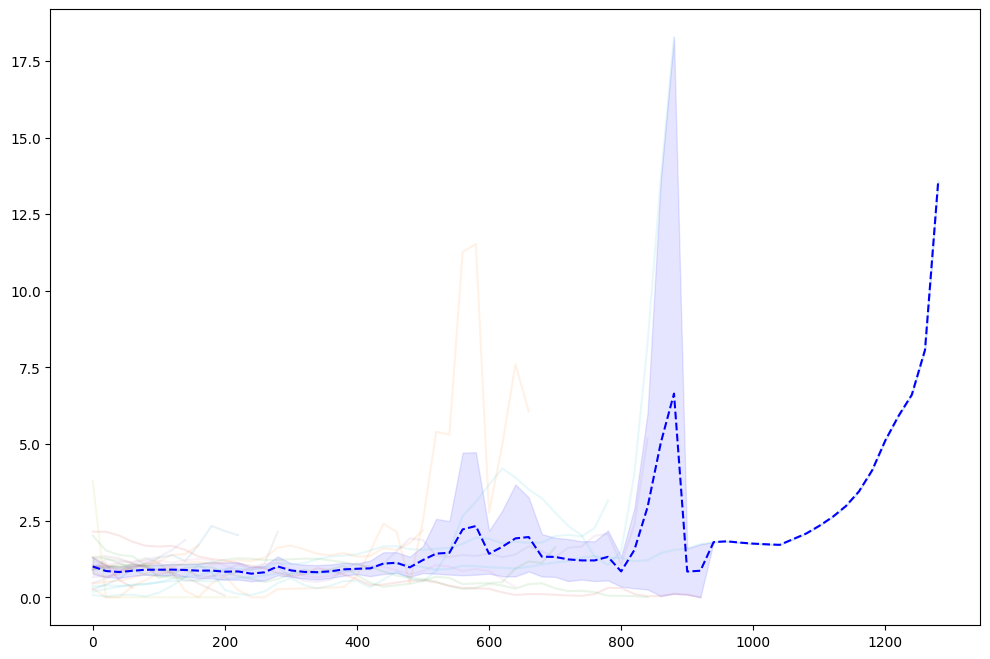

In [18]:
cell_types = ['WNT-high CRC stem-like cells']#, 'WNT-high CRC cells', 'Wnt-low CRC cells']

for cell_type in cell_types:
   shapedcrosspcfmedulla(list_of_domains, cell_type, 20, 40, 50, 200, visualise_shapes=False, collection_or_label = 'label', return_outputs = False)

In [ ]:
def shapedcrosspcfmedulla(list_of_domains, population, step, width, cortexstep, cortexwidth, visualise_shapes=False, collection_or_label = 'collection', return_outputs = False):
    """
    Carry out shaped cross-pcf analysis - returning the relative density of a given population in concentric regions within a shape.
    Warning: will take a long time to run if the population is large

    Parameters
    ----------
    domain : muspan domain
        The domain containing the objects.
    shape : collection
        The collection name of a shape within which you would like to carry out the shaped cross-pcf.
        Can be a collection of several shapes.
    population : collection or label
        the collection or label of the objects that you would like to compute the shaped cross-pcf metric for
    step : int
        the step between each ring in which the relative density is calculated
    width : int
        must be a multiple of step (for now), the width of the region in which relative density is calculated
    visualise_shapes : bool, optional
        defaults to False. Specifies whether you would like to visualise the concentric shapes in which the relative 
        densities are calculated
    collection_or_label : string
        defaults to 'collection'. Specifies whether your population entry is a collection or a label. Must be either
        'collection' or 'label'
    return_outputs : bool, optional
        defaults to False. Specifies whether you would like the relative densities, mean densities and confidence intervals returned. 
        If False, the function simply plots the output, if true, see returns.
    
        
    Returns
    -------
    all_densities : list
        A list of lists containing the relative densities of cells at each concentric region, from outermost to innermost. 
        Each sublist corresponds to a subshape of the specified shape.
    distances_from_boundary : list
        A list of the distances from the boundary of the outer edge of the ring. The indices of these distances correspond 
        to the indices of relative densities in the lists of all/relative densities and the confidence intervals of the densities.
    average_densities : list
        The average relative density for the ring at each distance from the shape boundary
    confidence_intervals : list
        The confidence intervals for the relative density for the ring at each distance from the shape boundary. Obtained by 
        bootstrapping across subregions 2000 times.
    """
    # celltypes = ['WNT-high CRC stem-like cells', 'WNT-high CRC cells', 'Wnt-low CRC cells']
    label_name = 'Detailed celltype (liver)'

    colours = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000']
    list_of_axes = []
    list_of_figs = []
    all_out_distances = []
    all_met_distances = []

    for dom in range(len(list_of_domains)):
        domain = list_of_domains[dom]
        met_no = met_nos[domains_order.index(str(domain.name))]
        one_domain_met_distances = []
        one_domain_out_distances = []
        for region_no in range(met_no):
            met_distances = np.load('../outputs/Useful_Data/'+str(domain.name)+'_inside_Met_'+str(region_no+1)+'.npy', allow_pickle=True)
            one_domain_met_distances.append(met_distances)
        out_distances = np.load('../outputs/Useful_Data/'+str(domain.name)+'_outside_to_all_Mets.npy', allow_pickle=True)
        # one_domain_out_distances.append(out_distances)
        all_out_distances.append(out_distances)
        all_met_distances.append(one_domain_met_distances)
    
    young_densities = []
    
    # fig_young, axes1 = plt.subplots(1, 1, figsize=(12, 8))
    
    for dom in range(2):
        fig, axes = plt.subplots(1, 1, figsize=(12, 8))
        ages = ['4d', '28d']
        axes.set_title('Relatice densities of ' + str(population) + ' in ' + str(ages[dom]) + ' old samples.')
        axes.set_xlabel('Distance from Met Boundary.')
        axes.set_ylabel('Relative Density.')
        list_of_axes.append(axes)
        list_of_figs.append(fig)
    # fig2, axes2 = plt.subplots(1, 1, figsize=(12, 8))
    list_of_max_met_dists = []
    all_regional_max_met_dists = []
    all_met_areas = []
    max_areas = []
    for dom in range(len(list_of_domains)):
        domain = list_of_domains[dom]
        met_no = met_nos[domains_order.index(str(domain.name))]
        # domain.estimate_boundary('rectangle')
        # met distances
        max_met_dist=0
        regional_max_met_dists = []
        shape_cell_distances = all_met_distances[dom]
        met_areas = []
        for region_no in range(met_no):
            distances = shape_cell_distances[region_no][1]#[sublist[1] for sublist in shape_cell_distances[region_no]]
            regional_max_met_dists.append(np.max(distances))
            if np.max(distances) > max_met_dist:
                max_met_dist = np.max(distances)
            # print(domain)
            # ms.visualise.visualise(domain,objects_to_plot=('collection', 'Metastasis '+str(region_no+1)))
            met_areas.append(ms.geometry.area(domain, population=('collection', 'Metastasis '+str(region_no+1)))[0])
        all_met_areas.append(met_areas)
        max_areas.append(np.max(met_areas))        
        list_of_max_met_dists.append(max_met_dist)
        all_regional_max_met_dists.append(regional_max_met_dists)
    max_met_area = np.max(max_areas)

    for dom in range(len(list_of_domains)):

        domain = list_of_domains[dom]
        met_no = met_nos[domains_order.index(str(domain.name))]
        if '4d' in str(domain.name):
            age = 0
        elif '28d' in str(domain.name):
            age = 1
        if width % step != 0:
            raise Exception('Width must be divisible by step')
        # set up plot
        if visualise_shapes == True:
            colours = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000']
            fig, axes = plt.subplots(1, 1, figsize=(8, 8))

        # find all subshapes in shape collection
       
        all_densities = []
        alt_all_densities = []
        # loop through each subshape
        for region_no in range(met_no): 
            shapes_ID=ms.query.interpret_query(ms.query.query(domain, ('collection',),'is','Metastasis '+str(region_no+1)))
            # print(shapes_ID)
            shape_ID = shapes_ID[0]

            ### Calculate distance to boundary from these points
            shape_cells = ms.query.return_object_IDs_from_query_like(domain, ('collection', 'Cell Centres in Met '+str(region_no+1)),bypass_checks=True) 
            
            ### Calculate densities in each region
            # export vertices of shape from MuSpAn
            shape_single = domain.objects[shape_ID]
            vs_ext = domain.vertices[shape_single.vertices].tolist()
            poly = gdstk.Polygon(vs_ext)

            if shape_single.internal_vertices:   
                internal_shapes_list = []
                for internal_shape in shape_single.internal_vertices:
                    vs_int = domain.vertices[internal_shape].tolist()
                    internal_shapes_list.append(gdstk.Polygon(vs_int))
                for inner in internal_shapes_list:
                    poly = gdstk.boolean(poly, inner, "not")
                area = poly[0].area()
            else:
                area = poly.area()
        
            all_offset_shapes = []
            
            areas = []
            i = 0
            while area > 0:
            # find offset polygon for each step
                eroded = gdstk.offset(poly, -i,
                                use_union=True, layer=1)
                offset_shapes = []
                offset_shapes_areas = []
                for j in range(len(eroded)):
                    offset_shapes_areas.append(eroded[j].area())
                    offset_shapes.append(eroded[j])
                    if visualise_shapes == True:
                        xs = [x[0] for x in eroded[j].points]
                        xs.append(xs[0])
                        ys = [x[1] for x in eroded[j].points]
                        ys.append(ys[0])
                        axes.plot(xs, ys, color = colours[math.floor(i) % len(colours)])

                if offset_shapes == []:
                    area = 0
                else:
                    area = np.max(np.array(offset_shapes_areas))
                all_offset_shapes.append(offset_shapes)
                areas.append(offset_shapes_areas)
                i +=step
        

            # Find areas of each region
            widthsteprat = int(width/step)
            ring_areas = []

            for depth in range(len(areas)-widthsteprat-1):
                ring_areas.append(np.sum(areas[depth])-np.sum(areas[depth+widthsteprat]))

            # find cell densities in each region

            ### Come back to this later to go over multiple cell types
            cell_type = population
            if collection_or_label == 'collection':
                query_cell = ms.query.query(domain, ('collection',), 'is', cell_type)
            else:
                query_cell = ms.query.query(domain, ('label', 'Detailed celltype (liver)'), 'is', cell_type)
            specific_cell_IDs = ms.query.return_object_IDs_from_query_like(domain,query_cell,bypass_checks=True)

            ### for multiple cell types in population, need to add filter to distances first
            shape_cell_distances = all_met_distances[dom][region_no]
            ### count number of cells of interest in total region and in each specific strip
            if len(areas)-widthsteprat-1 > 0:
                ranges = list(zip(range(0, (len(areas)-int(widthsteprat)-1)*step, step), range(width, (len(areas)-1)*step, step)))
                distances = [shape_cell_distances[1][i] for i in range(len(shape_cell_distances[0])) if shape_cell_distances[0][i] in specific_cell_IDs]
                # distances = [sublist[1] for sublist in shape_cell_distances if sublist[0] in specific_cell_IDs]
                # print(distances)
                total_cells, cell_counts = counts_for_ranges_numpy(distances, ranges)

                ### calculate overall density
                overall_density = total_cells/areas[0][0]
                # total_overall_density = all_cell_counts[dom]/met_areas[dom]

                densities = []
                rel_densities = []
                alt_densities = []

                ### calculate concentric relative densities
                for i in range(len(ring_areas)):
                    densities.append(cell_counts[i]/ring_areas[i])
                    rel_densities.append((cell_counts[i]/ring_areas[i])/overall_density)
                    # alt_densities.append((cell_counts[i]/ring_areas[i])/total_overall_density)
                x = np.linspace(0, 1, len(rel_densities)) # 1/(len(areas)-widthsteprat-1)
                area_met = all_met_areas[dom][region_no]
                color_temp = plt.cm.viridis(area_met/max_met_area)
                # print(domain.name)
                # print(age)
                list_of_axes[age].plot(x, rel_densities, alpha = 1, color = color_temp)
                list_of_axes[age].axhline(1, linestyle='--', color = 'black', linewidth=1, alpha = 0.5)
                # axes2.plot(x, alt_densities, alpha = 0.1)
                all_densities.append(rel_densities)
                # print(all_densities)
                alt_all_densities.append(alt_densities)

                if max_met_dist < (len(areas)-widthsteprat-1)*step:
                    max_met_dist = (len(areas)-widthsteprat-1)*step

        young_densities+=all_densities
        
    
    ### Bootstrap densities...    
    # average_young_densities = []
    # for items in zip_longest(*young_densities, fillvalue=None):
    #     # Filter out None and NaN
    #     valid = [x for x in items if x is not None and not (isinstance(x, float) and np.isnan(x))]
    #     if valid:
    #         # print(valid)
    #         average_young_densities.append(sum(valid) / len(valid))
    #     else:
    #         average_young_densities.append(float('nan')) 

    # n_valids, points, lo, hi = bootstrap_ci_positions_numpy(
    #     young_densities, n_bootstrap=2000, ci=95.0, statistic='mean', seed=42
    # )
    # x = np.linspace(0, 1, len(average_young_densities)) # 1/(len(average_young_densities)
    # axes1.plot(x, average_young_densities, linestyle = 'dashed', color = 'blue')
    # axes1.fill_between(x, lo, hi, color='blue', alpha=.1)
 
    if return_outputs == True:
        confidence_intervals = []
        # for a, b in zip(lo, hi):
        #     confidence_intervals.append( [ a, b ] )
        distances_from_boundary = x
        return all_densities, distances_from_boundary, average_young_densities, average_old_densities, confidence_intervals
 

AKPT_Liver_Mets_28d_2_Region_2
1
AKPT_Liver_Mets_28d_2_Region_2
1
AKPT_Liver_Mets_28d_2_Region_2
1
AKPT_Liver_Mets_4d_3_Region_1
0
AKPT_Liver_Mets_28d_2_Region_1
1
AKPT_Liver_Mets_28d_2_Region_1
1
AKPT_Liver_Mets_28d_2_Region_1
1
AKPT_Liver_Mets_28d_2_Region_1
1
AKPT_Liver_Mets_28d_2_Region_1
1
AKPT_Liver_Mets_28d_2_Region_1
1
AKPT_Liver_Mets_28d_2_Region_1
1
AKPT_Liver_Mets_28d_2_Region_1
1
AKPT_Liver_Mets_28d_2_Region_1
1
AKPT_Liver_Mets_28d_2_Region_1
1
AKPT_Liver_Mets_28d_1_Region_1
1
AKPT_Liver_Mets_28d_1_Region_1
1
AKPT_Liver_Mets_28d_1_Region_1
1
AKPT_Liver_Mets_28d_1_Region_1
1
AKPT_Liver_Mets_28d_1_Region_1
1
AKPT_Liver_Mets_28d_1_Region_1
1
AKPT_Liver_Mets_28d_1_Region_1
1
AKPT_Liver_Mets_28d_1_Region_1
1
AKPT_Liver_Mets_28d_1_Region_1
1
AKPT_Liver_Mets_28d_3_Region_1
1
AKPT_Liver_Mets_28d_3_Region_1
1
AKPT_Liver_Mets_28d_3_Region_1
1
AKPT_Liver_Mets_28d_3_Region_1
1
AKPT_Liver_Mets_28d_3_Region_1
1
AKPT_Liver_Mets_28d_3_Region_1
1
AKPT_Liver_Mets_28d_1_Region_2
1
AKPT_Liver_

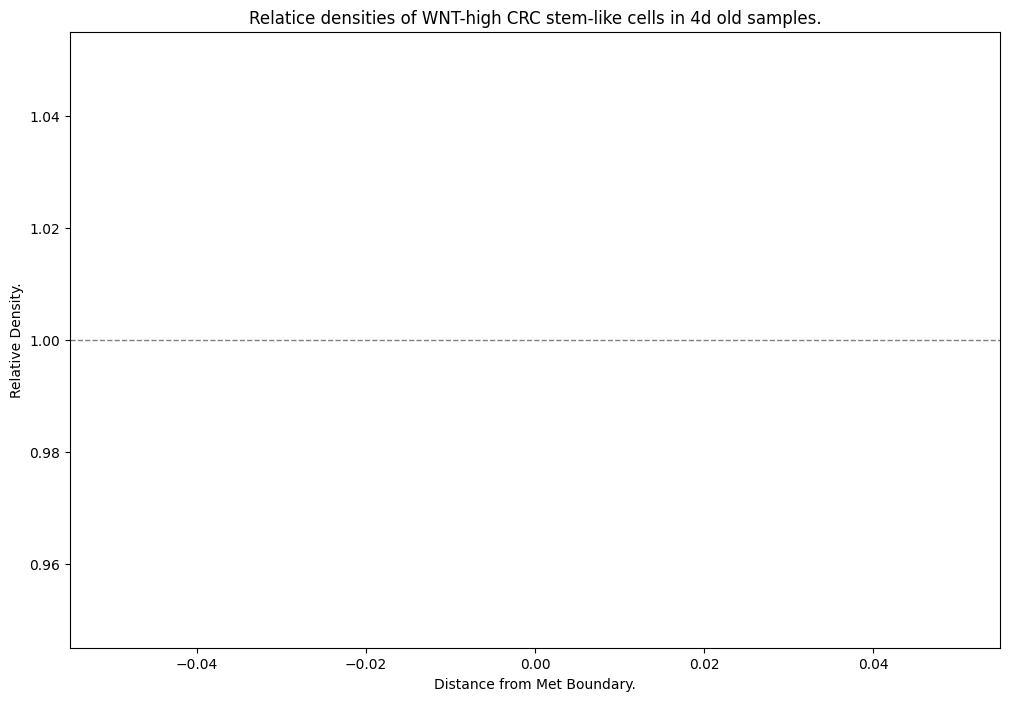

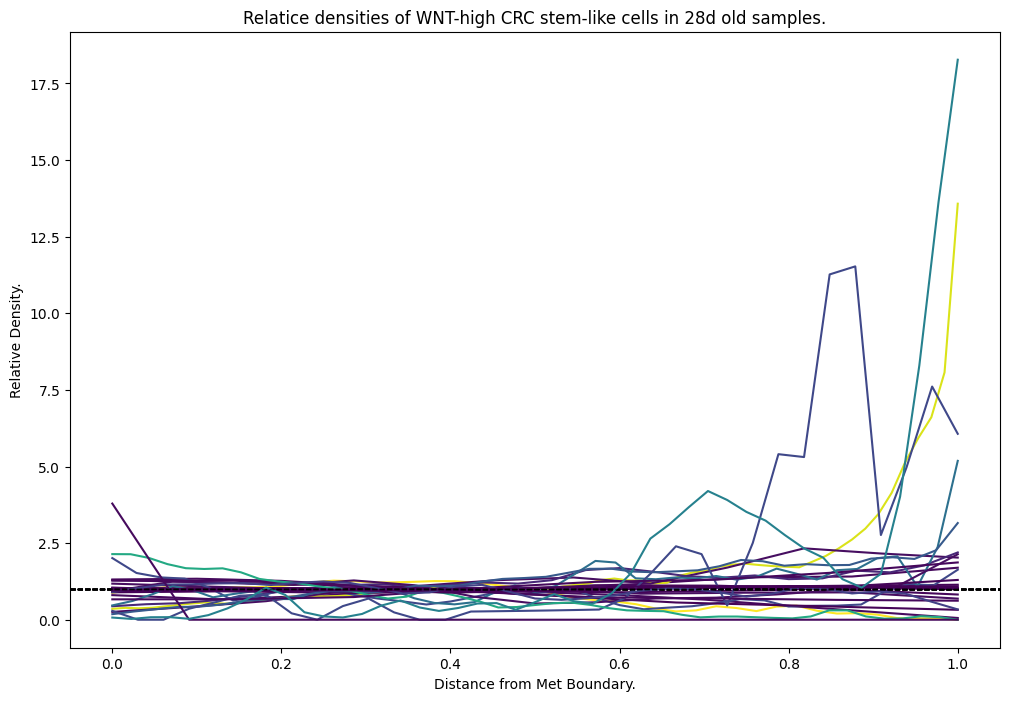

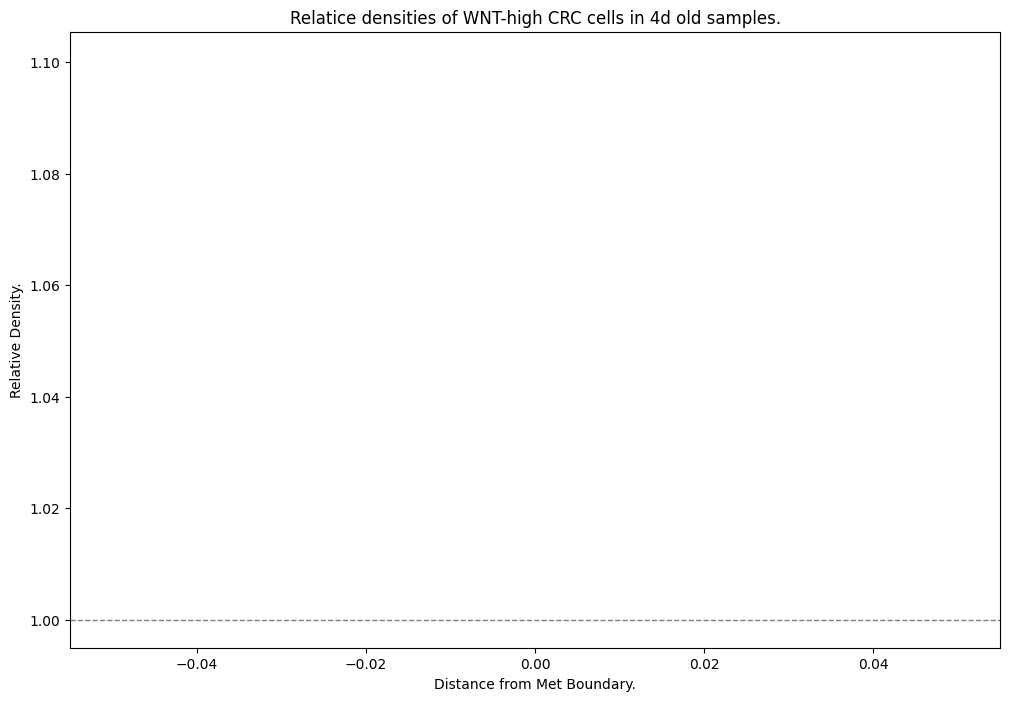

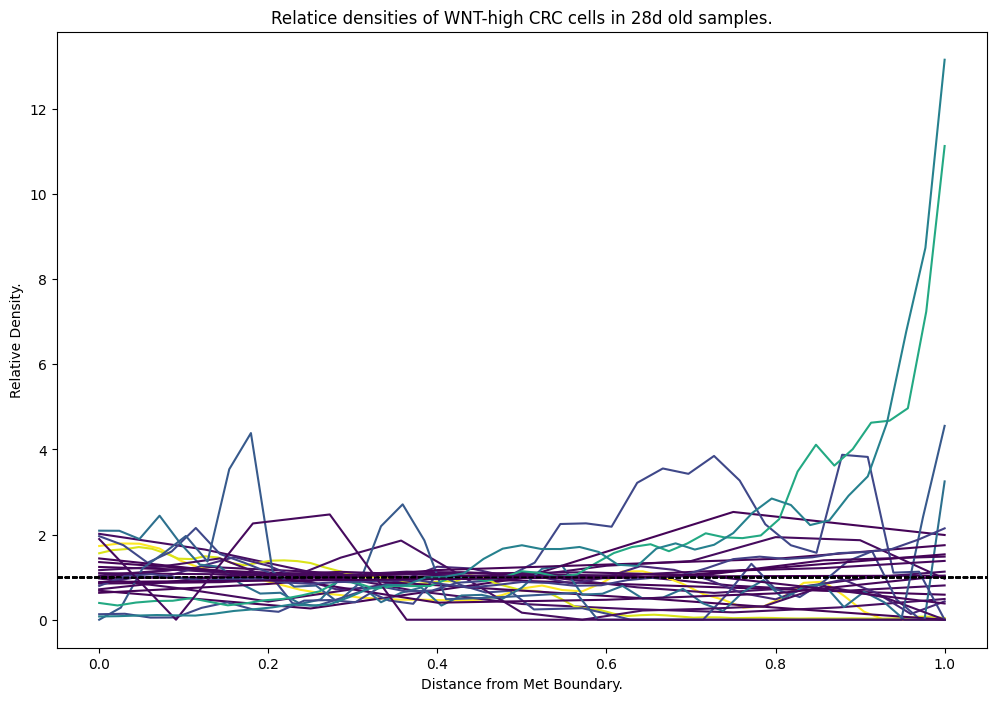

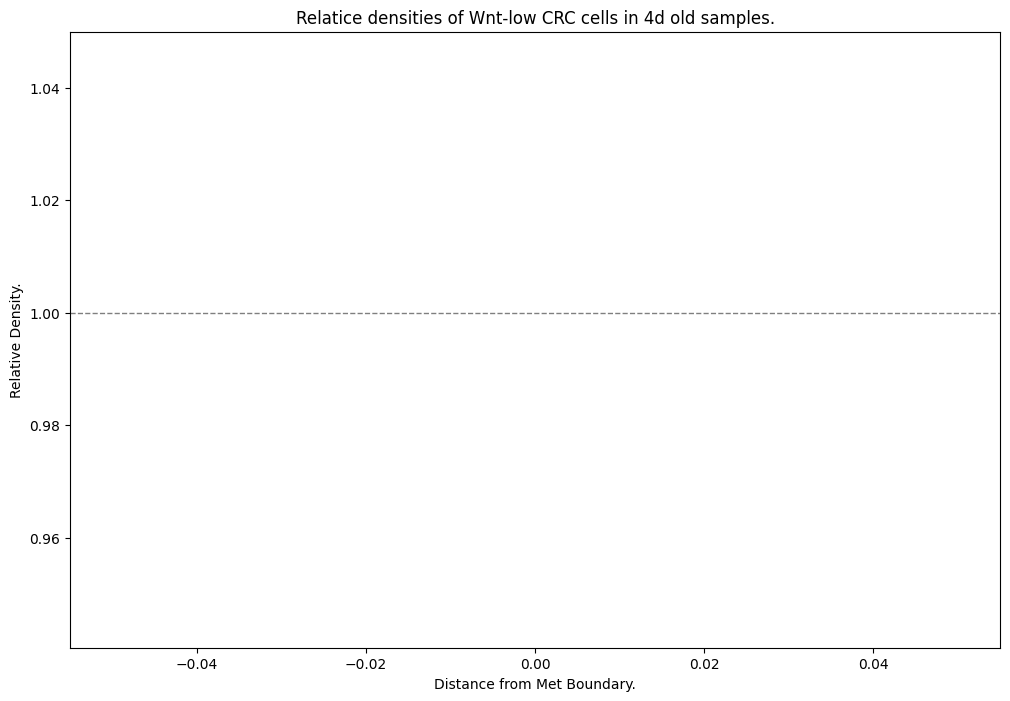

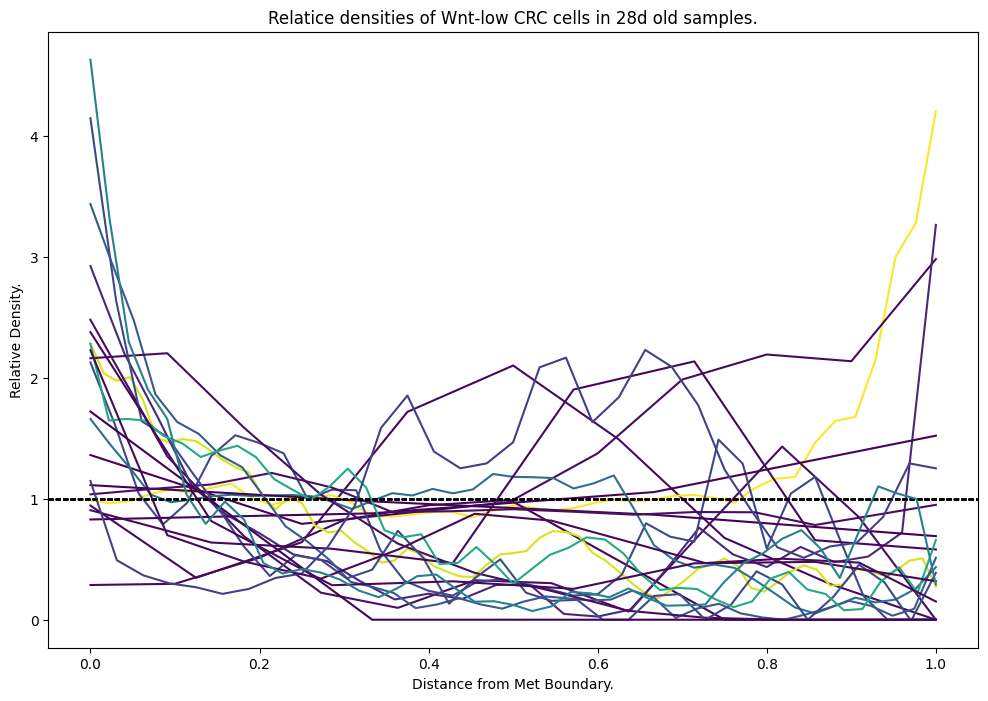

In [48]:
cell_types = ['WNT-high CRC stem-like cells', 'WNT-high CRC cells', 'Wnt-low CRC cells']

for cell_type in cell_types:
   shapedcrosspcfmedulla(list_of_domains, cell_type, 20, 40, 50, 200, visualise_shapes=False, collection_or_label = 'label', return_outputs = False)